In [6]:
# ==========================================================
# COMMON SETUP
# ==========================================================

!pip install scikit-learn seaborn matplotlib requests joblib

import os, requests, zipfile, random, cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import *

# -------------------------------
# DOWNLOAD GITHUB REPO
# -------------------------------
# check if we're running inside the repo already
if os.path.exists('face_embeddings.npz'): 
    print("Running locally inside the repository. Skipping download.")
    repo_root = '.'

# if not, download the repo as a zip and extract it
else:
    url = "https://github.com/spitlrr/facial_recognition/archive/refs/heads/main.zip"
    print(f"Empty environment detected. Downloading {url}...")
    
    r = requests.get(url, stream=True)
    with open("repo.zip", "wb") as f:
        for chunk in r.iter_content(8192):
            f.write(chunk)
            
    with zipfile.ZipFile("repo.zip", "r") as zip_ref:
        zip_ref.extractall() 
        
    print("Download and extraction complete.")
    repo_root = 'facial_recognition-main'

print(f"Active project root set to: {os.path.abspath(repo_root)}")

# -------------------------------
# FIND FILES
# -------------------------------
embedding_file = None
preprocess_folder = None

for root, dirs, files in os.walk(repo_root):
    if "face_embeddings.npz" in files:
        embedding_file = os.path.join(root,"face_embeddings.npz")
    if "preprocess_aligned" in dirs:
        preprocess_folder = os.path.join(root,"preprocess_aligned")

# -------------------------------
# LOAD DATA
# -------------------------------
data = np.load(embedding_file, allow_pickle=True)

X_train = data["train_embeddings"]
y_train = data["train_labels"]
X_val   = data["val_embeddings"]
y_val   = data["val_labels"]
X_test  = data["test_embeddings"]
y_test  = data["test_labels"]
test_paths = data["test_paths"]

# -------------------------------
# ENCODE + SCALE
# -------------------------------
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc   = le.transform(y_val)
y_test_enc  = le.transform(y_test)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# -------------------------------
# IMAGE HELPER
# -------------------------------
def show_predictions(model, name):
    print(f"\n🔍 {name} - 3 RANDOM TEST PREDICTIONS\n")

    for i in random.sample(range(len(X_test)), 3):

        sample = X_test[i].reshape(1,-1)
        pred = model.predict(sample)[0]
        pred_label = le.inverse_transform([pred])[0]

        if hasattr(model, "predict_proba"):
            conf = model.predict_proba(sample).max()
        else:
            conf = 1.0

        true_label = y_test[i]
        img_path = test_paths[i]

        if not os.path.exists(img_path):
            fname = os.path.basename(img_path)
            for root, dirs, files in os.walk(preprocess_folder):
                if fname in files:
                    img_path = os.path.join(root,fname)
                    break

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        print("True:", true_label, "| Pred:", pred_label, "| Conf:", round(conf,3))

        plt.imshow(img)
        plt.title(f"{name}\nTrue:{true_label} | Pred:{pred_label}")
        plt.axis("off")
        plt.show()

Defaulting to user installation because normal site-packages is not writeable
Running locally inside the repository. Skipping download.
Active project root set to: c:\Users\Owner\Documents\GitHub\facial_recognition


k = 1 Val Acc: 0.967741935483871
k = 3 Val Acc: 0.967741935483871
k = 5 Val Acc: 0.967741935483871
k = 7 Val Acc: 0.967741935483871

Best KNN Val Accuracy: 0.967741935483871

KNN TEST RESULTS
Accuracy: 0.9831932773109243
Precision: 0.9899159663865545
Recall: 0.9831932773109243
F1-Score: 0.9843182434264028

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      1.00      1.00        18
           2       1.00      1.00      1.00         3
           3       0.60      1.00      0.75         3
           4       1.00      0.67      0.80         3
           5       1.00      1.00      1.00        11
           6       1.00      1.00      1.00        20
           7       1.00      1.00      1.00         1
           8       1.00      0.94      0.97        16
           9       1.00      1.00      1.00         7
          10       1.00      1.00      1.00        18
          11       

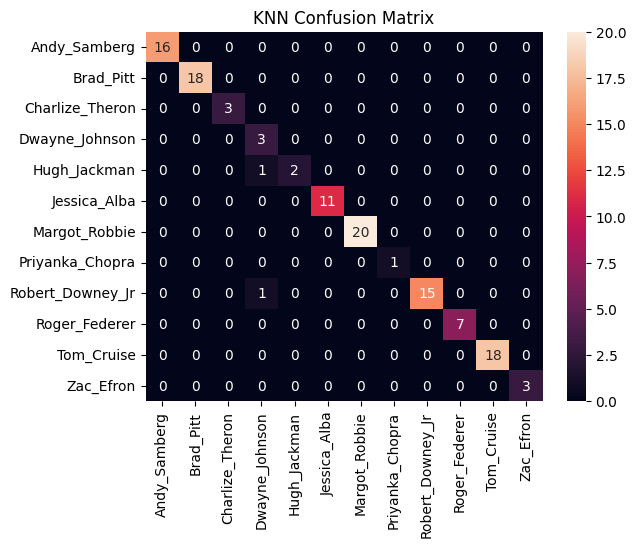


🔍 KNN - 3 RANDOM TEST PREDICTIONS

True: Margot_Robbie | Pred: Margot_Robbie | Conf: 1.0


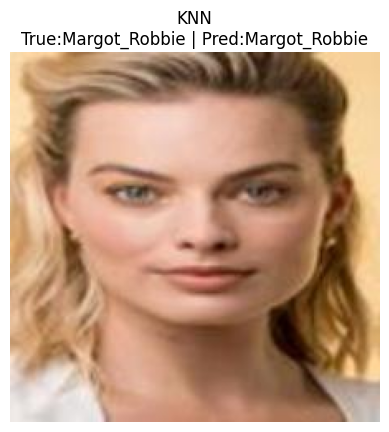

True: Brad_Pitt | Pred: Brad_Pitt | Conf: 1.0


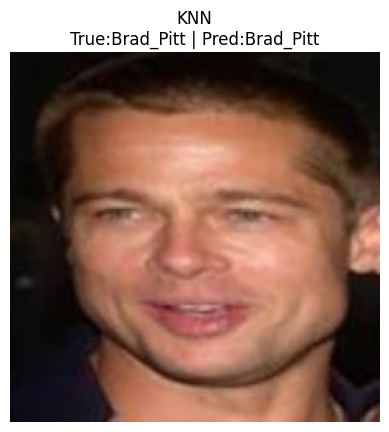

True: Roger_Federer | Pred: Roger_Federer | Conf: 1.0


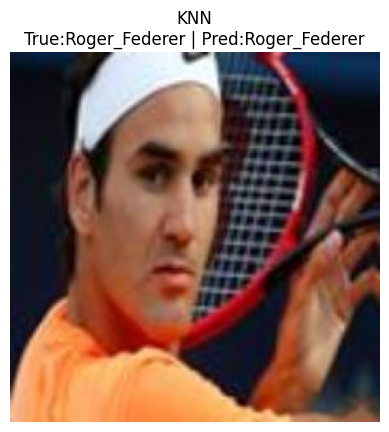

In [7]:
# FACE RECOGNITION MODEL 1 - KNN
from sklearn.neighbors import KNeighborsClassifier

best_acc = 0
best_model = None

for k in [1,3,5,7]:

    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train_enc)

    val_pred = model.predict(X_val)
    acc = accuracy_score(y_val_enc, val_pred)

    print("k =", k, "Val Acc:", acc)

    if acc > best_acc:
        best_acc = acc
        best_model = model

print("\nBest KNN Val Accuracy:", best_acc)

# TEST
knn_pred = best_model.predict(X_test)

print("\nKNN TEST RESULTS")
print("Accuracy:", accuracy_score(y_test_enc,knn_pred))
print("Precision:", precision_score(y_test_enc, knn_pred, average='weighted'))
print("Recall:", recall_score(y_test_enc, knn_pred, average='weighted'))
print("F1-Score:", f1_score(y_test_enc, knn_pred, average='weighted'))
print("\nClassification Report:\n", classification_report(y_test_enc,knn_pred))

sns.heatmap(confusion_matrix(y_test_enc,knn_pred), annot=True,
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("KNN Confusion Matrix")
plt.show()

show_predictions(best_model, "KNN")

C = 0.01 Val Acc: 0.967741935483871
C = 0.1 Val Acc: 0.967741935483871
C = 1 Val Acc: 0.967741935483871
C = 10 Val Acc: 0.967741935483871

Best Logistic Val Accuracy: 0.967741935483871

LOGISTIC TEST RESULTS
Accuracy: 0.9663865546218487
Precision: 0.971030517470146
Recall: 0.9663865546218487
F1-Score: 0.9654596973924704

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       0.95      1.00      0.97        18
           2       1.00      1.00      1.00         3
           3       0.75      1.00      0.86         3
           4       1.00      0.67      0.80         3
           5       1.00      1.00      1.00        11
           6       1.00      1.00      1.00        20
           7       1.00      1.00      1.00         1
           8       0.94      0.94      0.94        16
           9       1.00      0.71      0.83         7
          10       1.00      1.00      1.00        18
    

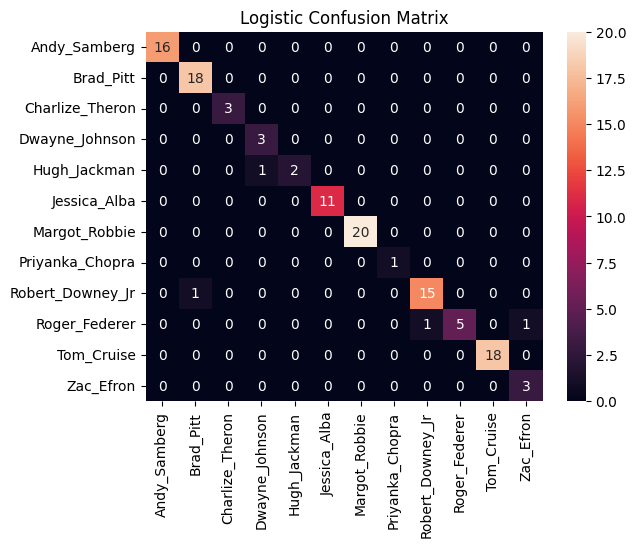


🔍 Logistic - 3 RANDOM TEST PREDICTIONS

True: Charlize_Theron | Pred: Charlize_Theron | Conf: 0.475


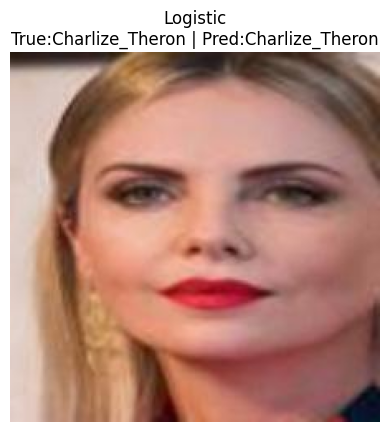

True: Robert_Downey_Jr | Pred: Brad_Pitt | Conf: 0.153


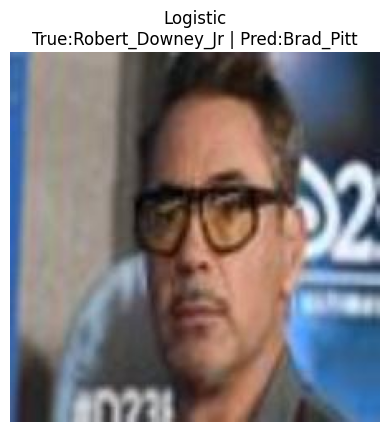

True: Margot_Robbie | Pred: Margot_Robbie | Conf: 0.372


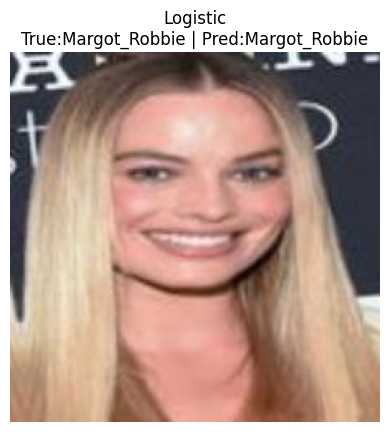

In [8]:
# FACE RECOGNITION MODEL 2 - LOGISTIC REGRESSION
from sklearn.linear_model import LogisticRegression

best_acc = 0
best_model = None

for C in [0.01,0.1,1,10]:

    model = LogisticRegression(C=C, max_iter=5000)
    model.fit(X_train, y_train_enc)

    val_pred = model.predict(X_val)
    acc = accuracy_score(y_val_enc, val_pred)

    print("C =", C, "Val Acc:", acc)

    if acc > best_acc:
        best_acc = acc
        best_model = model

print("\nBest Logistic Val Accuracy:", best_acc)

# TEST
log_pred = best_model.predict(X_test)

print("\nLOGISTIC TEST RESULTS")
print("Accuracy:", accuracy_score(y_test_enc,log_pred))
print("Precision:", precision_score(y_test_enc, log_pred, average='weighted'))
print("Recall:", recall_score(y_test_enc, log_pred, average='weighted'))
print("F1-Score:", f1_score(y_test_enc, log_pred, average='weighted'))
print("\nClassification Report:\n", classification_report(y_test_enc,log_pred))

sns.heatmap(confusion_matrix(y_test_enc,log_pred), annot=True,
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Logistic Confusion Matrix")
plt.show()

show_predictions(best_model, "Logistic")

linear 0.1 Val Acc: 0.967741935483871
linear 1 Val Acc: 0.967741935483871
linear 10 Val Acc: 0.967741935483871
rbf 0.1 Val Acc: 0.12903225806451613
rbf 1 Val Acc: 0.967741935483871
rbf 10 Val Acc: 0.967741935483871

Best SVM Val Accuracy: 0.967741935483871

SVM TEST RESULTS
Accuracy: 0.9831932773109243
Precision: 0.9836355594869527
Recall: 0.9831932773109243
F1-Score: 0.9831712981618105

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       0.94      0.94      0.94        18
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00         3
           4       1.00      1.00      1.00         3
           5       1.00      1.00      1.00        11
           6       1.00      1.00      1.00        20
           7       1.00      1.00      1.00         1
           8       1.00      0.94      0.97        16
           9       1.00      1.00      1.00 

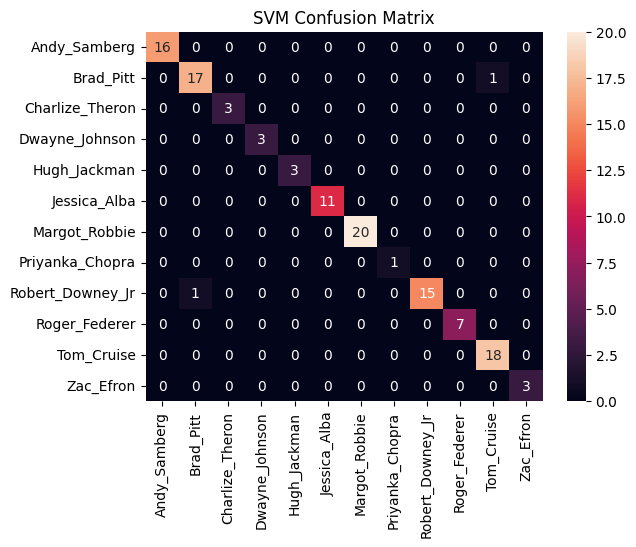


🔍 SVM - 3 RANDOM TEST PREDICTIONS

True: Brad_Pitt | Pred: Brad_Pitt | Conf: 0.416


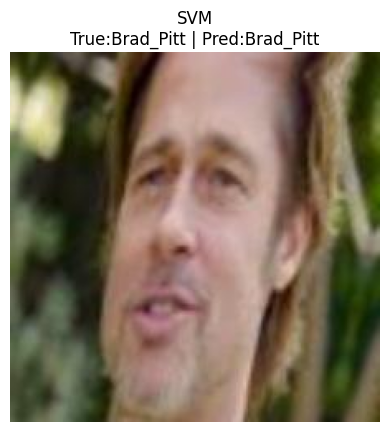

True: Jessica_Alba | Pred: Jessica_Alba | Conf: 0.559


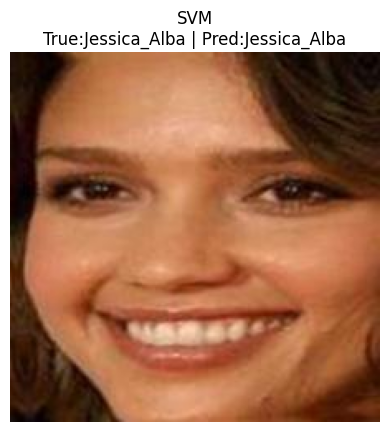

True: Tom_Cruise | Pred: Tom_Cruise | Conf: 0.765


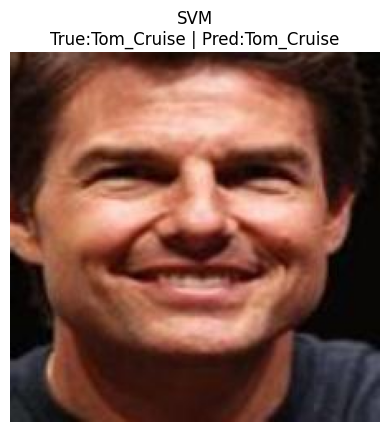

In [9]:
# FACE RECOGNITION MODEL 3 - SUPPORT VECTOR MACHINE (SVM)
from sklearn.svm import SVC

best_acc = 0
best_model = None

for kernel in ['linear','rbf']:
    for C in [0.1,1,10]:

        model = SVC(kernel=kernel, C=C, probability=True)
        model.fit(X_train, y_train_enc)

        val_pred = model.predict(X_val)
        acc = accuracy_score(y_val_enc, val_pred)

        print(kernel, C, "Val Acc:", acc)

        if acc > best_acc:
            best_acc = acc
            best_model = model

print("\nBest SVM Val Accuracy:", best_acc)

# TEST
svm_pred = best_model.predict(X_test)

print("\nSVM TEST RESULTS")
print("Accuracy:", accuracy_score(y_test_enc,svm_pred))
print("Precision:", precision_score(y_test_enc, svm_pred, average='weighted'))
print("Recall:", recall_score(y_test_enc, svm_pred, average='weighted'))
print("F1-Score:", f1_score(y_test_enc, svm_pred, average='weighted'))
print("\nClassification Report:\n", classification_report(y_test_enc,svm_pred))

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test_enc,svm_pred), annot=True,
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("SVM Confusion Matrix")
plt.show()

show_predictions(best_model, "SVM")

Cosine Val Accuracy: 0.967741935483871

COSINE TEST RESULTS
Accuracy: 0.9831932773109243
Precision: 0.9899159663865545
Recall: 0.9831932773109243
F1-Score: 0.9843182434264028

Classification Report:
                   precision    recall  f1-score   support

    Andy_Samberg       1.00      1.00      1.00        16
       Brad_Pitt       1.00      1.00      1.00        18
 Charlize_Theron       1.00      1.00      1.00         3
  Dwayne_Johnson       0.60      1.00      0.75         3
    Hugh_Jackman       1.00      0.67      0.80         3
    Jessica_Alba       1.00      1.00      1.00        11
   Margot_Robbie       1.00      1.00      1.00        20
 Priyanka_Chopra       1.00      1.00      1.00         1
Robert_Downey_Jr       1.00      0.94      0.97        16
   Roger_Federer       1.00      1.00      1.00         7
      Tom_Cruise       1.00      1.00      1.00        18
       Zac_Efron       1.00      1.00      1.00         3

        accuracy                           0

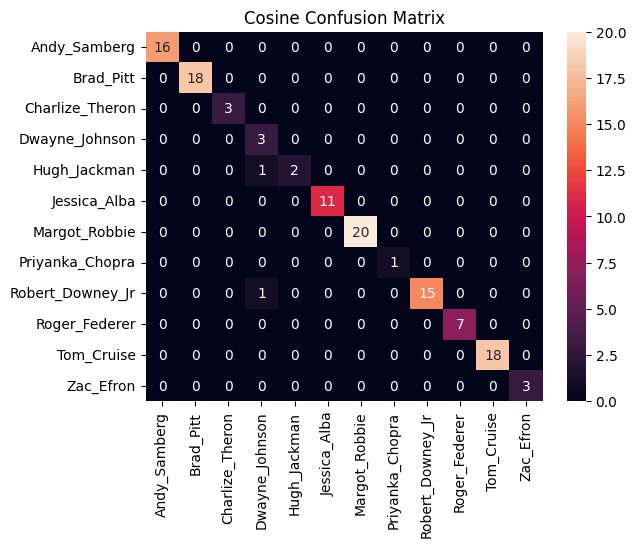


🔍 Cosine - 3 RANDOM TEST PREDICTIONS

True: Jessica_Alba | Pred: Jessica_Alba | Sim: 0.768


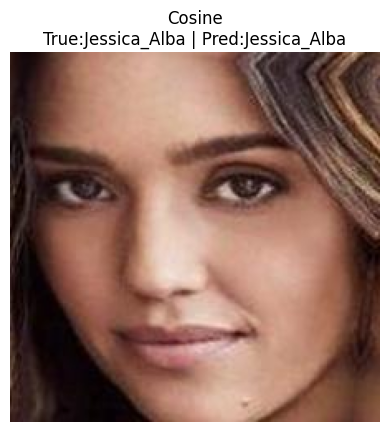

True: Jessica_Alba | Pred: Jessica_Alba | Sim: 0.767


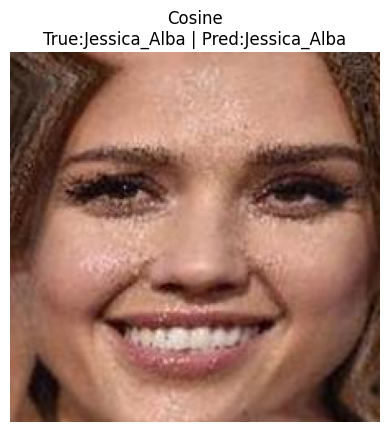

True: Margot_Robbie | Pred: Margot_Robbie | Sim: 1.0


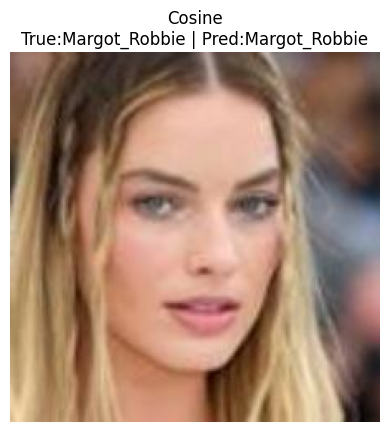

In [10]:
# FACE RECOGNITION MODEL 4 - COSINE SIMILARITY
from sklearn.metrics.pairwise import cosine_similarity

def predict_cosine(test_emb):
    sims = cosine_similarity([test_emb], X_train)[0]
    idx = np.argmax(sims)
    return y_train[idx], sims[idx]

# VALIDATION
val_preds = []
for emb in X_val:
    label,_ = predict_cosine(emb)
    val_preds.append(label)

print("Cosine Val Accuracy:", accuracy_score(y_val_enc, le.transform(val_preds)))


# TEST
test_preds = []
for emb in X_test:
    label,_ = predict_cosine(emb)
    test_preds.append(label)

print("\nCOSINE TEST RESULTS")
print("Accuracy:", accuracy_score(y_test,test_preds))
print("Precision:", precision_score(y_test, test_preds, average='weighted'))
print("Recall:", recall_score(y_test, test_preds, average='weighted'))
print("F1-Score:", f1_score(y_test, test_preds, average='weighted'))
print("\nClassification Report:\n", classification_report(y_test,test_preds))

sns.heatmap(confusion_matrix(y_test,test_preds,labels=le.classes_),
            annot=True, xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Cosine Confusion Matrix")
plt.show()

# VISUALIZE 3
print("\n🔍 Cosine - 3 RANDOM TEST PREDICTIONS\n")

for i in random.sample(range(len(X_test)), 3):

    pred_label, conf = predict_cosine(X_test[i])
    true_label = y_test[i]

    img_path = test_paths[i]

    if not os.path.exists(img_path):
        fname = os.path.basename(img_path)
        for root, dirs, files in os.walk(preprocess_folder):
            if fname in files:
                img_path = os.path.join(root,fname)
                break

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    print("True:", true_label, "| Pred:", pred_label, "| Sim:", round(float(conf),3))

    plt.imshow(img)
    plt.title(f"Cosine\nTrue:{true_label} | Pred:{pred_label}")
    plt.axis("off")
    plt.show()